##Import library yg akan digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Memuat Data

In [3]:
df=pd.read_csv('data_anak_stunting_temanggung.csv')
print("=== 5 baris data set pertama ===")
print(df.head())

=== 5 baris data set pertama ===
   id jenis_data id_anak jenis_kelamin tanggal_lahir tanggal_pengukuran  \
0   1       Anak   A0001     Perempuan     5/29/2025          10/1/2025   
1   2       Anak   A0002     Laki-laki     6/17/2024          10/1/2025   
2   3       Anak   A0003     Perempuan     9/12/2023          10/1/2025   
3   4       Anak   A0004     Laki-laki    10/17/2024          10/1/2025   
4   5       Anak   A0005     Laki-laki     4/29/2023          10/1/2025   

   usia_bulan  tinggi_badan_cm  skor_z_haz  status_stunting kecamatan  \
0         4.1             52.1       -2.32  Stunting Ringan  Gemawang   
1        15.5             79.5       -2.56  Stunting Ringan  Gemawang   
2        24.6            105.9       -0.73           Normal  Gemawang   
3        11.5             73.3        0.91           Normal  Gemawang   
4        29.1            113.2       -0.77           Normal  Gemawang   

        desa  
0  Tlogorejo  
1  Ngadisepi  
2     Losari  
3  Ngadisepi  
4 

##EDA(Exploratory data analyst)

In [4]:
print("info dataset")
print(df.info())

info dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  2200 non-null   int64  
 1   jenis_data          2200 non-null   object 
 2   id_anak             2200 non-null   object 
 3   jenis_kelamin       2200 non-null   object 
 4   tanggal_lahir       2200 non-null   object 
 5   tanggal_pengukuran  2200 non-null   object 
 6   usia_bulan          2200 non-null   float64
 7   tinggi_badan_cm     2200 non-null   float64
 8   skor_z_haz          2200 non-null   float64
 9   status_stunting     2200 non-null   object 
 10  kecamatan           2200 non-null   object 
 11  desa                2200 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 206.4+ KB
None


==== visualisasi data


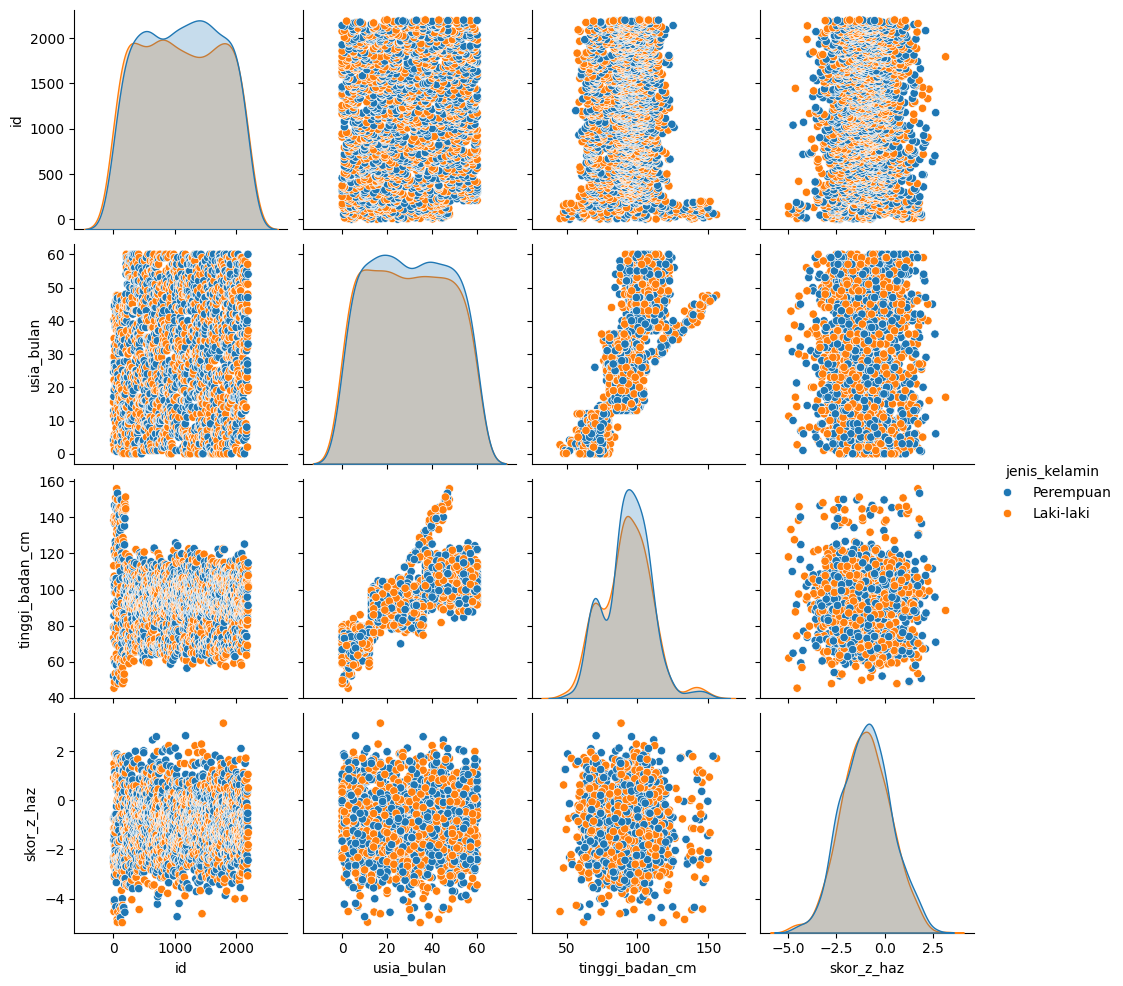

In [5]:
print("==== visualisasi data")
sns.pairplot(df, hue='jenis_kelamin' )
plt.show()

In [6]:
# MENGUBAH DATA JENIS KELAMIN DAN TANGGAL LAHIR MENJADI BINNER
# jenis kelamin
# tanngal lahir tahunnya
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  2200 non-null   int64  
 1   jenis_data          2200 non-null   object 
 2   id_anak             2200 non-null   object 
 3   jenis_kelamin       2200 non-null   object 
 4   tanggal_lahir       2200 non-null   object 
 5   tanggal_pengukuran  2200 non-null   object 
 6   usia_bulan          2200 non-null   float64
 7   tinggi_badan_cm     2200 non-null   float64
 8   skor_z_haz          2200 non-null   float64
 9   status_stunting     2200 non-null   object 
 10  kecamatan           2200 non-null   object 
 11  desa                2200 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 206.4+ KB


In [7]:
df = pd.read_csv("data_anak_stunting_temanggung.csv")

# --- Ubah tanggal_lahir menjadi tahun lahir ---
df['tanggal_lahir'] = pd.to_datetime(df['tanggal_lahir'], errors='coerce')
df['tahun_lahir'] = df['tanggal_lahir'].dt.year

# --- Ubah jenis_kelamin menjadi angka (1 = Laki-laki, 0 = Perempuan) ---
df['jenis_kelamin'] = df['jenis_kelamin'].map({'Laki-laki': 1, 'Perempuan': 0})

# Lihat hasilnya
print(df[['jenis_kelamin', 'tanggal_lahir', 'tahun_lahir']].head())

   jenis_kelamin tanggal_lahir  tahun_lahir
0              0    2025-05-29         2025
1              1    2024-06-17         2024
2              0    2023-09-12         2023
3              1    2024-10-17         2024
4              1    2023-04-29         2023


In [8]:
print("==== korelasi dataset ====")
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)
print(numeric_df.corr())

==== korelasi dataset ====
                       id  jenis_kelamin  usia_bulan  tinggi_badan_cm  \
id               1.000000      -0.017055    0.064873        -0.062650   
jenis_kelamin   -0.017055       1.000000   -0.017576        -0.020778   
usia_bulan       0.064873      -0.017576    1.000000         0.770738   
tinggi_badan_cm -0.062650      -0.020778    0.770738         1.000000   
skor_z_haz       0.021785      -0.016838    0.002655        -0.016021   
tahun_lahir     -0.022849       0.035184   -0.048319        -0.120639   

                 skor_z_haz  tahun_lahir  
id                 0.021785    -0.022849  
jenis_kelamin     -0.016838     0.035184  
usia_bulan         0.002655    -0.048319  
tinggi_badan_cm   -0.016021    -0.120639  
skor_z_haz         1.000000     0.018097  
tahun_lahir        0.018097     1.000000  


In [9]:
print("==== Deskripsi dataset =====")
print(df.describe())

==== Deskripsi dataset =====
                id  jenis_kelamin                  tanggal_lahir   usia_bulan  \
count  2200.000000    2200.000000                           2200  2200.000000   
mean   1100.500000       0.489091  2023-07-11 23:15:29.454545408    29.701591   
min       1.000000       0.000000            2021-01-01 00:00:00     0.000000   
25%     550.750000       0.000000            2022-03-26 00:00:00    15.000000   
50%    1100.500000       0.000000            2023-07-19 00:00:00    30.000000   
75%    1650.250000       1.000000            2024-10-16 00:00:00    45.000000   
max    2200.000000       1.000000            2025-12-28 00:00:00    60.000000   
std     635.229617       0.499995                            NaN    17.403160   

       tinggi_badan_cm   skor_z_haz  tahun_lahir  
count      2200.000000  2200.000000  2200.000000  
mean         92.640091    -0.980214  2023.034545  
min          45.300000    -4.970000  2021.000000  
25%          81.800000    -1.850000  

In [10]:
print("==== Duplikasi dataset =====")
print(df.duplicated().sum())

==== Duplikasi dataset =====
0


In [11]:
print("==== jumlah missing value ====")
print(df.isnull().sum())

==== jumlah missing value ====
id                    0
jenis_data            0
id_anak               0
jenis_kelamin         0
tanggal_lahir         0
tanggal_pengukuran    0
usia_bulan            0
tinggi_badan_cm       0
skor_z_haz            0
status_stunting       0
kecamatan             0
desa                  0
tahun_lahir           0
dtype: int64


==== Cek Outlier Pada Data ====


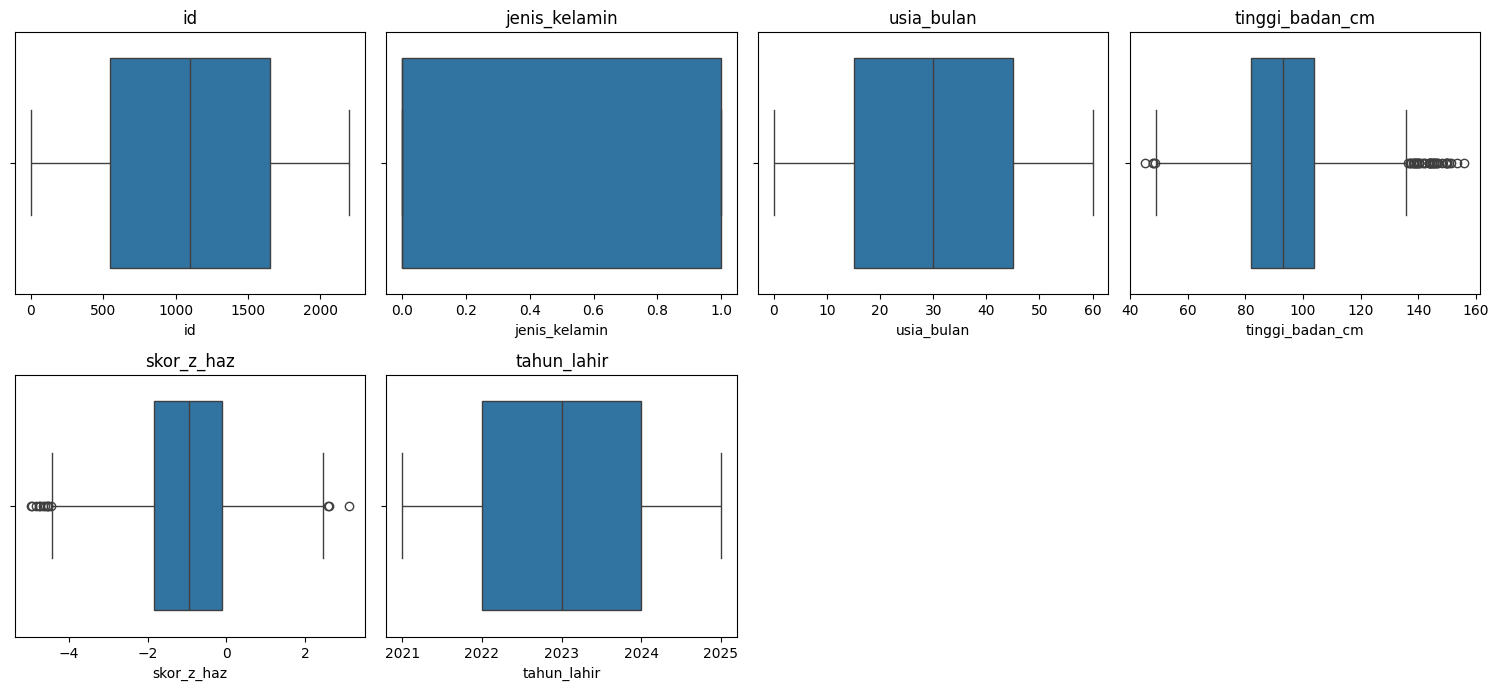

In [12]:
print("==== Cek Outlier Pada Data ====")
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
# Remove the 'id' column as it's not a feature for outlier analysis

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

=== Visualisasi Data ====


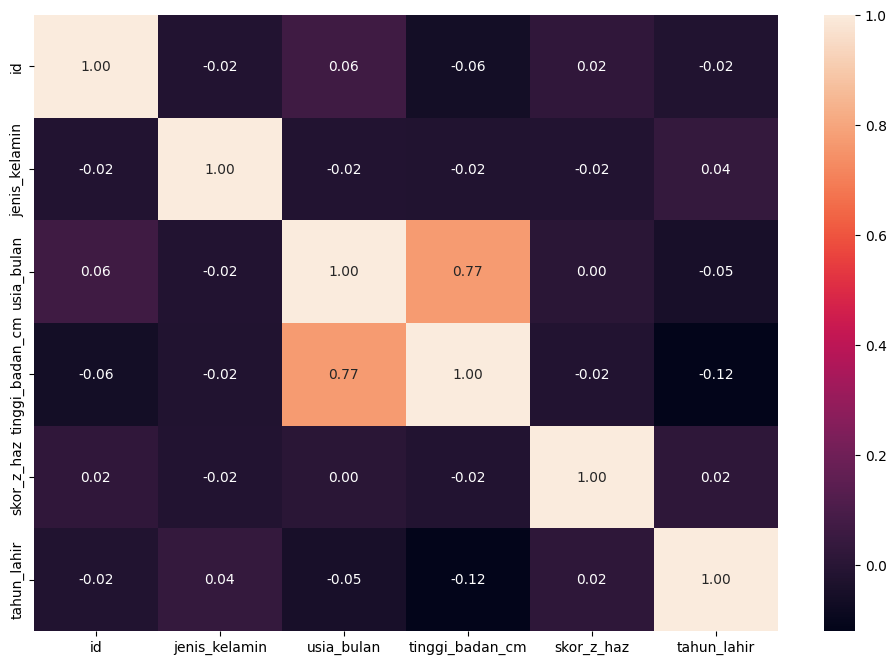

In [13]:
print("=== Visualisasi Data ====")
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f")
plt.show()

==== visualisasi data ====


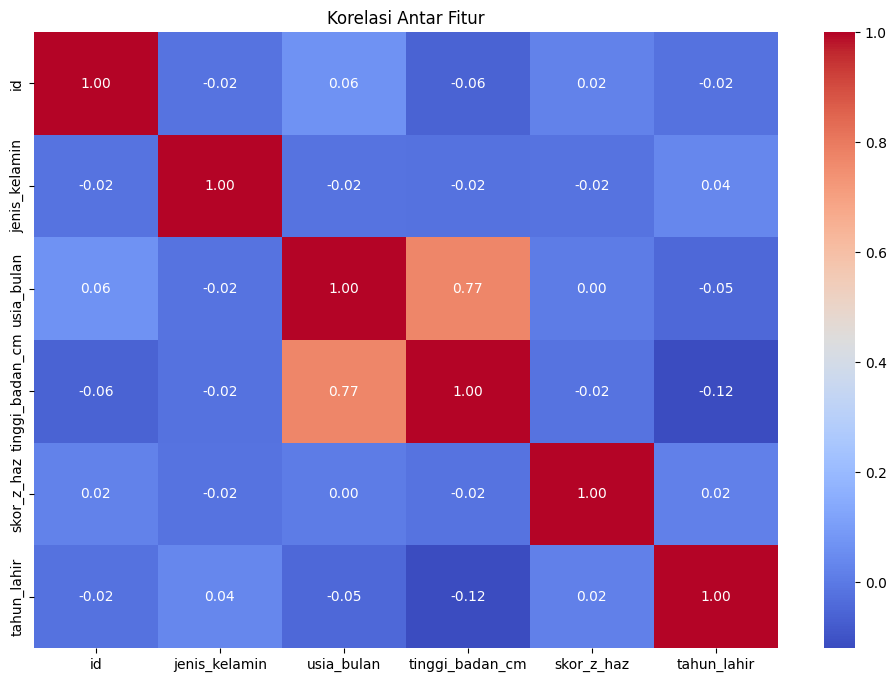

In [14]:
print("==== visualisasi data ====")
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Korelasi Antar Fitur')
plt.show()